In [ ]:
import pandas as pd
import numpy as np
import os
import seaborn as sns

# --- 1. Setup & Helpers ---
matrix_path = "/home/mengelsl/MA-bench-framework/matrices/spmv"
main_folder = {
    "NativeVM": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/native/",
    "SMEVM": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sme/",
    "SEVVM": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sev/",
    "NativeVM_interleave": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/native_interleave/",
    "SMEVM_interleave": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sme_interleave/",
    "SEVVM_interleave": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sev_interleave/",
}

def get_mb(n, randomness):
    r_str = str(randomness).replace('.', '-')
    f_path = os.path.join(matrix_path, f"{r_str}_N{int(n)}.bin")
    try:
        return round(os.path.getsize(f_path) / (1024**2))
    except: return None

def apply_metadata(df, label):
    df = df.rename(columns={'NUMA_Policy': 'Process_NUMA'})
    df['VM_NUMA'] = 'interleave' if 'interleave' in label else 'strict'
    df['Mode'] = label.replace('_interleave', '')
    return df

results_list = []
for label, path in main_folder.items():
    f_path = os.path.join(path, "results.csv")
    if os.path.exists(f_path):
        df = pd.read_csv(f_path)
        df = apply_metadata(df, label)
        # Extract Matrix info
        df['N'] = df['Matrix'].str.extract(r'N(\d+)').fillna(0).astype(int)
        r = df['Matrix'].str.extract(r'(\d)-(\d)')
        df['Randomness'] = (r[0] + "." + r[1]).astype(float).fillna(0.0)
        df['MB'] = df.apply(lambda row: get_mb(row['N'], row['Randomness']), axis=1).astype('Int64')
        k = 30  # nnz per row
        df['SpMV_GFLOPS'] = ( 2 * k * df['N']) / ( (df['SpMV_Time'] / df['Iterations']) * 1e9)
        results_list.append(df)

df_raw = pd.concat(results_list, ignore_index=True)
metrics = ['IO_Time', 'SpMV_Time', 'SpMV_GFLOPS', 'Perf_Cycles', 'Perf_Instructions', 'Perf_CacheMisses', 'Perf_dTLBMisses', 'Voluntary_CtxSwitches', 'Involuntary_CtxSwitches', 'Minor_Faults', 'Major_Faults', 'Peak_RSS']
# These are the columns that define a unique configuration and do not change per configuration.
config_cols = ['Mode', 'Matrix', 'Cores', 'Process_NUMA', 'VM_NUMA', 'N', 'Randomness', 'MB', 'Iterations']

def iqr_clean(g):
    res = {}
    for c in metrics:
        q1, q3 = g[c].quantile([0.25, 0.75])
        iqr = q3 - q1
        filtered = g[c][(g[c] >= q1 - 1.5*iqr) & (g[c] <= q3 + 1.5*iqr)]
        res[c] = filtered.mean() if not filtered.empty else g[c].median()
    return pd.Series(res)

df = df_raw.groupby(config_cols).apply(iqr_clean,include_groups=False).reset_index()
print(f"Loaded {len(df)} cleaned configurations.")

Loaded 480 cleaned configurations.


In [36]:
df

,Mode,Matrix,Cores,Process_NUMA,VM_NUMA,N,Randomness,MB,Iterations,IO_Time,...,SpMV_GFLOPS,Perf_Cycles,Perf_Instructions,Perf_CacheMisses,Perf_dTLBMisses,Voluntary_CtxSwitches,Involuntary_CtxSwitches,Minor_Faults,Major_Faults,Peak_RSS
0,NativeVM,0-0_N1440352.bin,1,interleave,interleave,1440352,0.0,500,369,0.081598,...,3.205450,3.613541e+10,1.993093e+11,3.293954e+06,363828.533333,0.0,19.466667,7.0,0.0,535676.0
1,NativeVM,0-0_N1440352.bin,1,interleave,strict,1440352,0.0,500,369,0.081996,...,3.191015,3.630301e+10,1.993093e+11,3.276777e+06,396131.642857,0.0,16.466667,7.0,0.0,535676.0
2,NativeVM,0-0_N1440352.bin,1,membind,interleave,1440352,0.0,500,369,0.081822,...,3.206251,3.612827e+10,1.993093e+11,3.276651e+06,346667.800000,0.0,20.785714,7.0,0.0,535676.0
3,NativeVM,0-0_N1440352.bin,1,membind,strict,1440352,0.0,500,369,0.081674,...,3.191684,3.630452e+10,1.993093e+11,3.248815e+06,345576.933333,0.0,16.733333,7.0,0.0,535676.0
4,NativeVM,0-0_N1440352.bin,8,interleave,interleave,1440352,0.0,500,713,0.081576,...,6.000488,2.962678e+11,3.852641e+11,1.557499e+07,16662.933333,0.0,101.200000,17.0,0.0,540250.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,SMEVM,1-0_N8642110.bin,24,membind,strict,8642110,1.0,3000,79,0.482813,...,3.842339,9.264509e+11,2.568642e+11,2.142652e+10,72579.928571,0.0,220.500000,51.0,0.0,3208080.0
476,SMEVM,1-0_N8642110.bin,48,interleave,interleave,8642110,1.0,3000,83,0.468873,...,9.253262,8.084599e+11,2.704553e+11,2.218936e+10,98957.000000,0.0,257.600000,101.0,0.0,3212828.0
477,SMEVM,1-0_N8642110.bin,48,interleave,strict,8642110,1.0,3000,83,0.481374,...,4.363211,1.697602e+12,2.697114e+11,2.318874e+10,104524.000000,0.0,440.733333,101.0,0.0,3212828.0
478,SMEVM,1-0_N8642110.bin,48,membind,interleave,8642110,1.0,3000,84,0.467857,...,9.240787,8.193625e+11,2.737534e+11,2.242669e+10,98923.000000,0.0,273.400000,101.0,0.0,3212828.0


In [ ]:
# --- 4. Load Iteration Detail ---
# This takes ~1-2 minutes
iter_list = []

for label, base_path in main_folder.items():
    extra_path = os.path.join(base_path, "extra")
    if not os.path.exists(extra_path): continue
    
    for folder in os.listdir(extra_path):
        csv_p = os.path.join(extra_path, folder, "iter.csv")
        match = re.search(r'(\d-\d)_N(\d+)_c(\d+)_(\w+)', folder)
        
        if os.path.exists(csv_p) and match:
            it_df = pd.read_csv(csv_p)
            it_df = apply_metadata(it_df, label)
            
            it_df['Randomness'] = float(match.group(1).replace('-', '.'))
            it_df['N'] = int(match.group(2))
            it_df['Cores'] = int(match.group(3))
            it_df['Process_NUMA'] = match.group(4)
            it_df['MB'] = get_mb(it_df['N'].iloc[0], it_df['Randomness'].iloc[0])
            
            iter_list.append(it_df)

df_iters = pd.concat(iter_list, ignore_index=True) if iter_list else pd.DataFrame()
print(f"Loaded {len(df_iters)} individual iterations.")

Loaded 408661650 individual iterations.


In [ ]:
#da stimmt was mit den gflops nicht

,Mode,Matrix,Cores,Process_NUMA,VM_NUMA,N,Randomness,MB,Iterations,IO_Time,...,SpMV_GFLOPS,Perf_Cycles,Perf_Instructions,Perf_CacheMisses,Perf_dTLBMisses,Voluntary_CtxSwitches,Involuntary_CtxSwitches,Minor_Faults,Major_Faults,Peak_RSS
0,NativeVM,0-0_N1440352.bin,1,interleave,interleave,1440352,0.0,500,369,0.081598,...,0.008687,3.613541e+10,1.993093e+11,3.293954e+06,363828.533333,0.0,19.466667,7.0,0.0,535676.0
1,NativeVM,0-0_N1440352.bin,1,interleave,strict,1440352,0.0,500,369,0.081996,...,0.008648,3.630301e+10,1.993093e+11,3.276777e+06,396131.642857,0.0,16.466667,7.0,0.0,535676.0
2,NativeVM,0-0_N1440352.bin,1,membind,interleave,1440352,0.0,500,369,0.081822,...,0.008689,3.612827e+10,1.993093e+11,3.276651e+06,346667.800000,0.0,20.785714,7.0,0.0,535676.0
3,NativeVM,0-0_N1440352.bin,1,membind,strict,1440352,0.0,500,369,0.081674,...,0.008650,3.630452e+10,1.993093e+11,3.248815e+06,345576.933333,0.0,16.733333,7.0,0.0,535676.0
4,NativeVM,0-0_N1440352.bin,8,interleave,interleave,1440352,0.0,500,713,0.081576,...,0.008416,2.962678e+11,3.852641e+11,1.557499e+07,16662.933333,0.0,101.200000,17.0,0.0,540250.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,SMEVM,1-0_N8642110.bin,24,membind,strict,8642110,1.0,3000,79,0.482813,...,0.048637,9.264509e+11,2.568642e+11,2.142652e+10,72579.928571,0.0,220.500000,51.0,0.0,3208080.0
476,SMEVM,1-0_N8642110.bin,48,interleave,interleave,8642110,1.0,3000,83,0.468873,...,0.111485,8.084599e+11,2.704553e+11,2.218936e+10,98957.000000,0.0,257.600000,101.0,0.0,3212828.0
477,SMEVM,1-0_N8642110.bin,48,interleave,strict,8642110,1.0,3000,83,0.481374,...,0.052569,1.697602e+12,2.697114e+11,2.318874e+10,104524.000000,0.0,440.733333,101.0,0.0,3212828.0
478,SMEVM,1-0_N8642110.bin,48,membind,interleave,8642110,1.0,3000,84,0.467857,...,0.110009,8.193625e+11,2.737534e+11,2.242669e+10,98923.000000,0.0,273.400000,101.0,0.0,3212828.0


<Axes: xlabel='Mode', ylabel='SpMV_GFLOPS'>

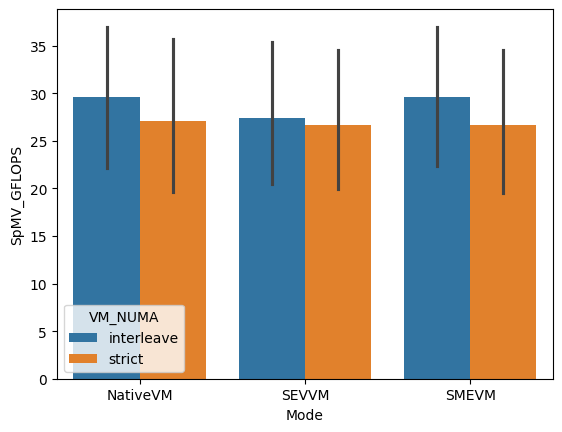

In [37]:
sns.barplot(data=df, x='Mode', y='SpMV_GFLOPS', hue='VM_NUMA')

In [ ]:
def compute_overhead(df_agg, mode, baseline_mode='NativeVM'):
    native = df_agg[df_agg['Mode'] == baseline_mode]
    other  = df_agg[df_agg['Mode'] == mode]

    merged = pd.merge(
        native,
        other,
        on=['Cores', 'MB', 'Randomness', 'NUMA_Policy'],
        suffixes=('_base', f'_{mode}')
    )

    merged['Overhead'] = (
        (merged[f'SpMV_Time_{mode}'] - merged['SpMV_Time_base'])
        / merged['SpMV_Time_base'] * 100
    )
    return merged

def plot_overhead_grid(df_overhead, title, vmin, vmax):
    numa_vals = sorted(df_overhead['NUMA_Policy'].unique())
    rand_vals = sorted(df_overhead['Randomness'].unique())

    fig, axes = plt.subplots(len(numa_vals), len(rand_vals),
                             figsize=(12, 8), sharex=True, sharey=True)

    abs_max = max(abs(vmin), abs(vmax))
    norm = TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

    for i, numa in enumerate(numa_vals):
        for j, rand in enumerate(rand_vals):
            ax = axes[i][j]

            subset = df_overhead[
                (df_overhead['NUMA_Policy'] == numa) &
                (df_overhead['Randomness'] == rand)
            ]

            pivot = subset.pivot(index='Cores', columns='MB', values='Overhead')

            sns.heatmap(
                pivot,
                ax=ax,
                cmap='RdYlGn_r', 
                norm=norm,
                annot=True,
                fmt=".1f"
            )

            ax.set_title(f"NUMA={numa}, Rand={rand}")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


df_sme_std = compute_overhead(df, 'SMEVM', 'NativeVM')
df_sev_std = compute_overhead(df, 'SEVVM', 'NativeVM')

df_sme_int = compute_overhead(df, 'SMEVM_interleave', 'NativeVM_interleave')
df_sev_int = compute_overhead(df, 'SEVVM_interleave', 'NativeVM_interleave')

std_min = min(df_sme_std['Overhead'].min(), df_sev_std['Overhead'].min())
std_max = max(df_sme_std['Overhead'].max(), df_sev_std['Overhead'].max())

plot_overhead_grid(df_sme_std, "SMEVM vs NativeVM Overhead (%)", std_min, std_max)
plot_overhead_grid(df_sev_std, "SEVVM vs NativeVM Overhead (%)", std_min, std_max)

int_min = min(df_sme_int['Overhead'].min(), df_sev_int['Overhead'].min())
int_max = max(df_sme_int['Overhead'].max(), df_sev_int['Overhead'].max())

plot_overhead_grid(df_sme_int, "SMEVM Interleave vs NativeVM Interleave Overhead (%)", int_min, int_max)
plot_overhead_grid(df_sev_int, "SEVVM Interleave vs NativeVM Interleave Overhead (%)", int_min, int_max)